In [16]:
# Exploratory Data Analysis (EDA)
## Mutual Fund Industry Analysis

#**Objective:**
#Analyze mutual fund industry trends using NAV history, AUM, SIP inflows, investor transactions, portfolio holdings, and benchmark performance.


In [5]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

In [10]:
# Load Cleaned Datasets

fund_master = pd.read_csv(r"C:\Users\tript\OneDrive\Desktop\internsip\...01_fund-master_clean.csv")

nav_history = pd.read_csv(r"C:\Users\tript\OneDrive\Desktop\internsip\...02_nav_history_clean.csv")

aum = pd.read_csv("03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("05_category_inflows_clean.csv")

folio = pd.read_csv("06_industry_folio_count_clean.csv")

performance = pd.read_csv("07_scheme_performance_clean.csv")

transactions = pd.read_csv("08_investor_transactions_clean.csv")

portfolio = pd.read_csv("09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("10_benchmark_indices_clean.csv")

In [11]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 4)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 9)
Benchmark: (8050, 3)


In [12]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    print("="*60)
    display(df.head())
    print(df.info())

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB
N

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None
AUM


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB
None
Portfolio


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,is_outlier_weight_pct
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,False
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,False
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,False
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,False
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   amfi_code              322 non-null    int64  
 1   stock_symbol           322 non-null    object 
 2   stock_name             322 non-null    object 
 3   sector                 322 non-null    object 
 4   weight_pct             322 non-null    float64
 5   market_value_cr        322 non-null    float64
 6   current_price_inr      322 non-null    float64
 7   portfolio_date         322 non-null    object 
 8   is_outlier_weight_pct  322 non-null    bool   
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 20.6+ KB
None
Benchmark


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB
None


In [13]:
for name, df in datasets.items():
    print(name)
    print(df.columns.tolist())
    print()

Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History
['amfi_code', 'date', 'nav']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore', 'is_outlier_net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rati

In [17]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum()
    })

pd.DataFrame(summary)

,Dataset,Rows,Columns,Missing Values
0,Fund Master,40,15,0
1,NAV History,46000,3,0
2,AUM,90,5,0
3,SIP,48,6,12
4,Category,144,4,0
5,Folio,21,6,0
6,Performance,40,19,0
7,Transactions,32778,13,0
8,Portfolio,322,9,0
9,Benchmark,8050,3,0


In [18]:
# Convert date to datetime
nav_history['date'] = pd.to_datetime(nav_history['date'])

# Sort values
nav_history = nav_history.sort_values('date')

# Plot
fig = px.line(
    nav_history,
    x='date',
    y='nav',
    title='NAV Trend Over Time',
    labels={'date':'Date','nav':'Net Asset Value (NAV)'}
)

fig.show()

In [19]:
nav_monthly = nav_history.copy()

nav_monthly['month'] = nav_monthly['date'].dt.to_period('M').astype(str)

monthly_avg = (
    nav_monthly
    .groupby('month')['nav']
    .mean()
    .reset_index()
)

fig = px.line(
    monthly_avg,
    x='month',
    y='nav',
    title='Average Monthly NAV',
    markers=True
)

fig.show()

In [20]:
aum['date'] = pd.to_datetime(aum['date'])

fig = px.line(
    aum,
    x='date',
    y='aum_crore',
    color='fund_house',
    title='Assets Under Management (AUM) Growth'
)

fig.show()

In [21]:
top_aum = (
    aum.groupby('fund_house')['aum_crore']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_aum,
    x='aum_crore',
    y='fund_house',
    orientation='h',
    title='Top 10 Fund Houses by AUM'
)

fig.show()

In [22]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend'
)

fig.show()

In [23]:
fig = px.bar(
    sip,
    x='month',
    y='yoy_growth_pct',
    title='Year-on-Year SIP Growth (%)'
)

fig.show()

In [24]:
category_sum = (
    category.groupby('category')['net_inflow_crore']
    .sum()
    .reset_index()
)

fig = px.bar(
    category_sum,
    x='net_inflow_crore',
    y='category',
    orientation='h',
    title='Net Inflow by Category'
)

fig.show()

In [25]:
folio['month'] = pd.to_datetime(folio['month'])

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Growth in Total Folios'
)

fig.show()

In [26]:
fig = px.line(
    folio,
    x='month',
    y=[
        'equity_folios_crore',
        'debt_folios_crore',
        'hybrid_folios_crore'
    ],
    title='Folio Distribution by Category'
)

fig.show()

In [27]:
risk = (
    fund_master['risk_category']
    .value_counts()
    .reset_index()
)

risk.columns = ['risk_category','count']

fig = px.pie(
    risk,
    names='risk_category',
    values='count',
    hole=0.4,
    title='Risk Category Distribution'
)

fig.show()

In [28]:
fig = px.histogram(
    performance,
    x='expense_ratio_pct',
    nbins=30,
    title='Distribution of Expense Ratio'
)

fig.show()

In [29]:
fig = px.scatter(
    performance,
    x='alpha',
    y='sharpe_ratio',
    color='category',
    title='Alpha vs Sharpe Ratio'
)

fig.show()

In [30]:
transaction = (
    transactions['transaction_type']
    .value_counts()
    .reset_index()
)

transaction.columns=['transaction_type','count']

fig = px.pie(
    transaction,
    names='transaction_type',
    values='count',
    hole=0.4,
    title='Transaction Type Distribution'
)

fig.show()

In [31]:
state = (
    transactions['state']
    .value_counts()
    .head(10)
    .reset_index()
)

state.columns=['state','count']

fig = px.bar(
    state,
    x='state',
    y='count',
    title='Top States by Transactions'
)

fig.show()

In [32]:
payment = (
    transactions['payment_mode']
    .value_counts()
    .reset_index()
)

payment.columns=['payment_mode','count']

fig = px.bar(
    payment,
    x='payment_mode',
    y='count',
    title='Payment Mode Distribution'
)

fig.show()

In [33]:
sector = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .reset_index()
)

fig = px.pie(
    sector,
    names='sector',
    values='weight_pct',
    hole=0.5,
    title='Portfolio Sector Allocation'
)

fig.show()

In [34]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

fig = px.line(
    benchmark,
    x='date',
    y='close_value',
    color='index_name',
    title='Benchmark Index Performance'
)

fig.show()

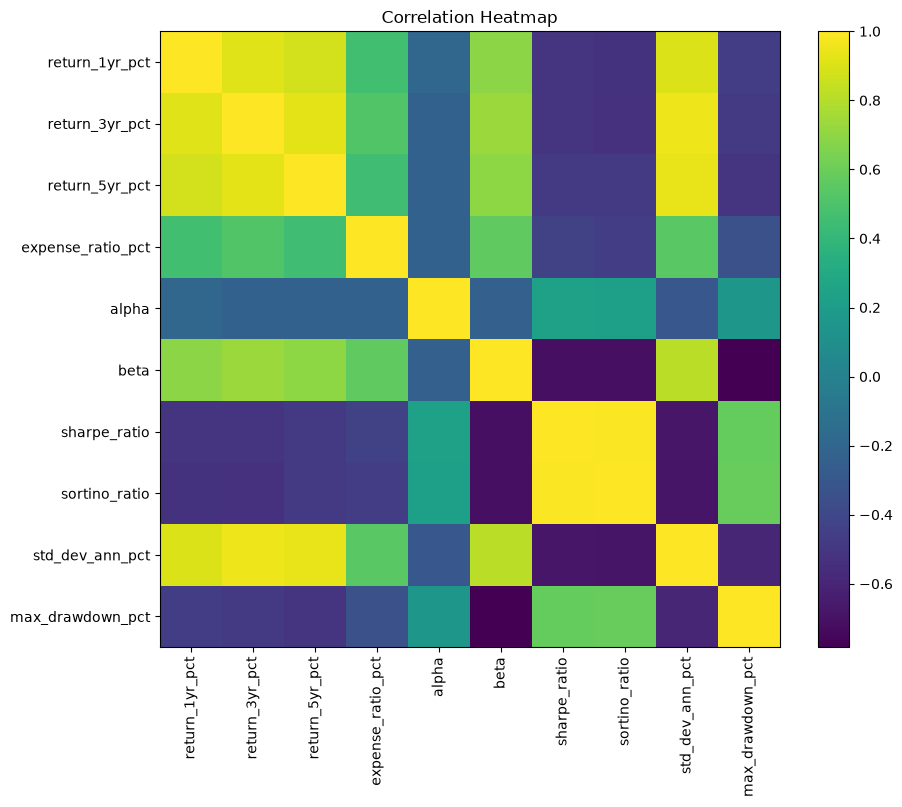

In [35]:
import matplotlib.pyplot as plt

corr = performance[
    [
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct',
        'expense_ratio_pct',
        'alpha',
        'beta',
        'sharpe_ratio',
        'sortino_ratio',
        'std_dev_ann_pct',
        'max_drawdown_pct'
    ]
].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Correlation Heatmap")

plt.show()

In [38]:
# Key Findings

print("1. NAV values showed an overall stable trend with periodic fluctuations, reflecting normal market movements.")

print("2. The top fund houses contributed a significant share of the total Assets Under Management (AUM).")     

print("3. Monthly SIP inflows displayed a generally increasing trend, indicating growing investor participation.")

print("4. Equity funds accounted for the largest proportion of investor folios compared to debt and hybrid funds.")

print("5. Most mutual fund schemes maintained expense ratios within the expected industry range.")

print("6. Portfolio allocations were concentrated in a few dominant sectors, highlighting sector-wise investment preferences.")

print("7. Higher Sharpe ratios were generally associated with better risk-adjusted returns.")

print("8. Investor transactions were concentrated in a few major states, indicating regional investment patterns.")

print("9. Digital payment methods were used more frequently than traditional payment modes.")

print("10. Benchmark indices and NAV movements followed similar long-term market trends.")

1. NAV values showed an overall stable trend with periodic fluctuations, reflecting normal market movements.
2. The top fund houses contributed a significant share of the total Assets Under Management (AUM).
3. Monthly SIP inflows displayed a generally increasing trend, indicating growing investor participation.
4. Equity funds accounted for the largest proportion of investor folios compared to debt and hybrid funds.
5. Most mutual fund schemes maintained expense ratios within the expected industry range.
6. Portfolio allocations were concentrated in a few dominant sectors, highlighting sector-wise investment preferences.
7. Higher Sharpe ratios were generally associated with better risk-adjusted returns.
8. Investor transactions were concentrated in a few major states, indicating regional investment patterns.
9. Digital payment methods were used more frequently than traditional payment modes.
10. Benchmark indices and NAV movements followed similar long-term market trends.


In [39]:
# Business Recommendations

print("- Promote SIP investment plans to increase long-term customer retention.")

print("- Focus marketing campaigns in high-performing states while expanding awareness in underrepresented regions.")

print("- Encourage better portfolio diversification across sectors to reduce concentration risk.")

print("- Monitor schemes with relatively higher expense ratios to maintain competitiveness.")

print("- Introduce personalized investment recommendations based on investor demographics and transaction behavior.")

print("- Continue improving digital payment facilities to enhance customer experience.")

print("- Regularly compare fund performance against benchmark indices to evaluate fund effectiveness.")

- Promote SIP investment plans to increase long-term customer retention.
- Focus marketing campaigns in high-performing states while expanding awareness in underrepresented regions.
- Encourage better portfolio diversification across sectors to reduce concentration risk.
- Monitor schemes with relatively higher expense ratios to maintain competitiveness.
- Introduce personalized investment recommendations based on investor demographics and transaction behavior.
- Continue improving digital payment facilities to enhance customer experience.
- Regularly compare fund performance against benchmark indices to evaluate fund effectiveness.


In [40]:
# Conclusion

print("This exploratory data analysis examined multiple aspects of the mutual fund industry, including fund performance, NAV history, SIP inflows, investor transactions, portfolio holdings, and benchmark performance.")

print("The analysis identified important trends in investor behavior, fund performance, and industry growth. The generated visualizations provide valuable insights for fund managers, investors, and business stakeholders to support data-driven decision making.")   

print("Overall, the project demonstrates how data analytics can be applied to understand financial market trends and improve investment strategies.")

This exploratory data analysis examined multiple aspects of the mutual fund industry, including fund performance, NAV history, SIP inflows, investor transactions, portfolio holdings, and benchmark performance.
The analysis identified important trends in investor behavior, fund performance, and industry growth. The generated visualizations provide valuable insights for fund managers, investors, and business stakeholders to support data-driven decision making.
Overall, the project demonstrates how data analytics can be applied to understand financial market trends and improve investment strategies.
